In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))
print(sys.path[-1])
import hbn_pl.io as io
import numpy as np
import hbn_pl.preprocess as preprocess
import hbn_pl.plot as plot
import hbn_pl.peaks2 as peaks2
import hbn_pl.classification2 as classification
import csv
import hbn_pl.peaks as peaks

c:\Users\ech77\OneDrive - University of Cambridge\2026\Code\hBN_PL\src


In [ ]:
DATA_DIR = Path("C://Users/ech77/OneDrive - University of Cambridge/Data Jan 2026/Large PL study, 0T")
FILE_NAME = '2026 January 23 15_30_17 Sample7_uncapped_500uW_grating150_exposure20_emitter 117.spe'
spe_path = DATA_DIR / FILE_NAME
wavelength, frames = io.load_spe(spe_path)

# pre-process and plot for visual check
frames = preprocess.background_subtract(frames, bg_slice=(1, 50))
#plot.plot_frames(frames, wavelength)

Performing background subtraction...
Successfully subtracted background.


Averaging and normalising frames into a single spectrum...
Successfully averaged and normalised frames.


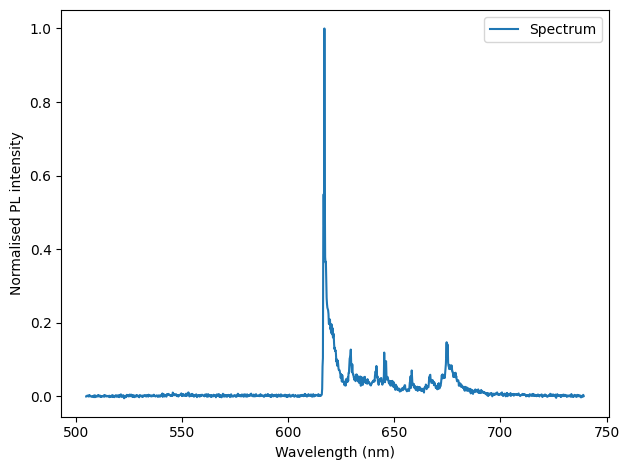

In [557]:
# average and normalise
avg, avg_norm = preprocess.average_and_normalise(frames)
plot.plot_spectrum(wavelength, avg_norm)

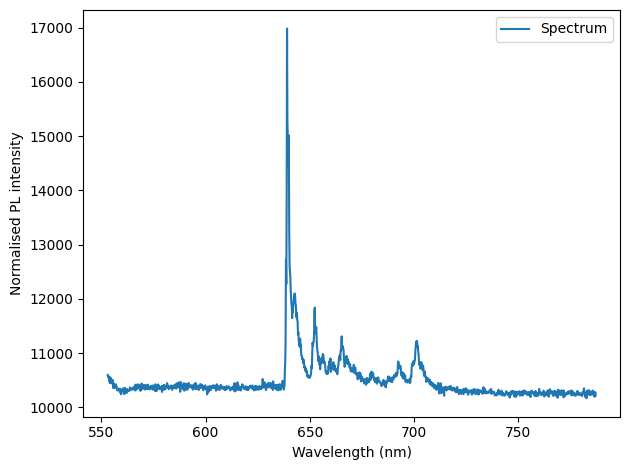

In [692]:
#import preprossessed data directly
DATA_DIR = Path("C://Users/ech77/OneDrive - University of Cambridge/Data for IBS November 2025/Sample 5/PL spectra")
FILE_NAME = '2025-11-18 18_54_59 sample5_DCMd2_200uw_emitter38 2217_cleaned_averaged.npz'

spe_path = DATA_DIR / FILE_NAME
data = np.load(spe_path)
wavelength = data["wavelength"]
avg_norm = data["spectra"]

plot.plot_spectrum(wavelength, avg_norm)

639.052486919128


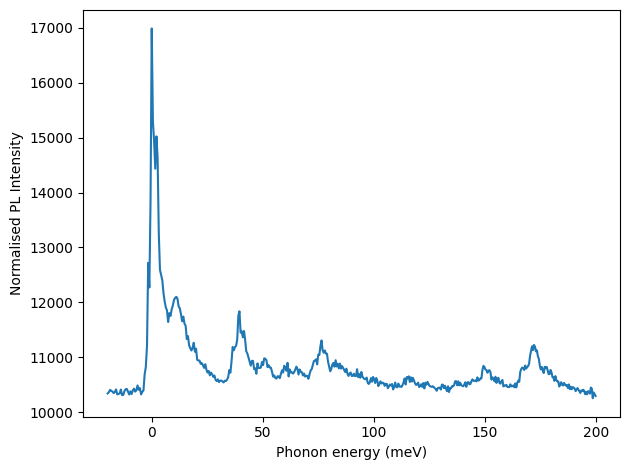

In [693]:
max_index = np.argmax(avg_norm)
zpl_wavelength = wavelength[max_index] #assuming ZPL is the most intense peak
print(zpl_wavelength)

intensity, energy = plot.plot_energy(avg_norm, wavelength, zpl_wavelength)

In [ ]:
targets = [11, 39, 150, 172]
window = 4
fit_results = []
print(zpl_wavelength)

for t in targets:
    res = peaks.fit_peak_gaussian(energy, intensity, target=t, window=window)
    print(f"Fitted center for target {t} meV: {res['center']:.2f} ± {res['center_err']:.2f} meV")
    fit_results.append(res)


639.052486919128
Fitted center for target 11 meV: 10.81 ± 0.09 meV
Fitted center for target 39 meV: 39.81 ± 0.23 meV
Fitted center for target 150 meV: 150.52 ± 0.19 meV
Fitted center for target 172 meV: 172.19 ± 0.09 meV


In [ ]:
io.save_spectrum_and_interactive_html(spe_path, energy, intensity, fit_results, targets, window=window)

Interactive figure saved to C:\Users\ech77\OneDrive - University of Cambridge\Data for IBS November 2025\Sample 5\PL spectra\2025-11-18 18_54_59 sample5_DCMd2_200uw_emitter38 2217_cleaned_averaged_interactive.html


Saved interactive plot: C:\Users\ech77\OneDrive - University of Cambridge\Data for IBS November 2025\Sample 5\PL spectra\2025-11-18 18_54_59 sample5_DCMd2_200uw_emitter38 2217_cleaned_averaged_interactive.html
Saved energy/intensity arrays: C:\Users\ech77\OneDrive - University of Cambridge\Data for IBS November 2025\Sample 5\PL spectra\2025-11-18 18_54_59 sample5_DCMd2_200uw_emitter38 2217_cleaned_averaged_energy.npz


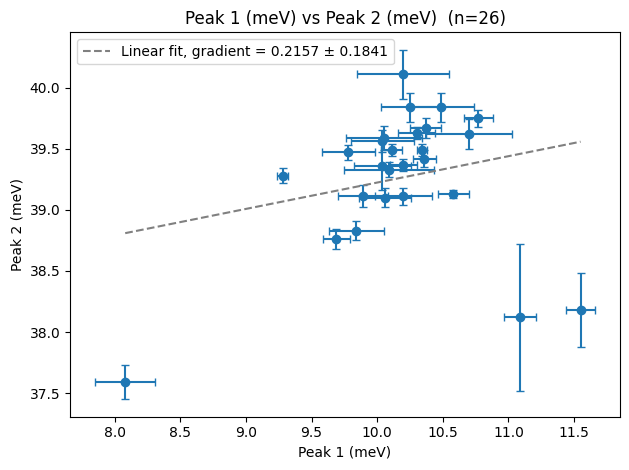

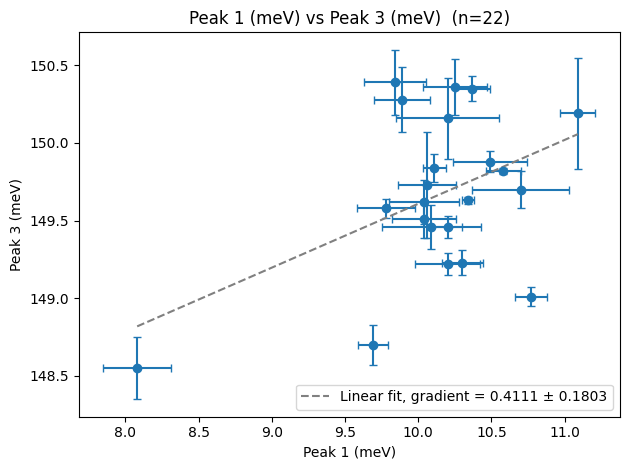

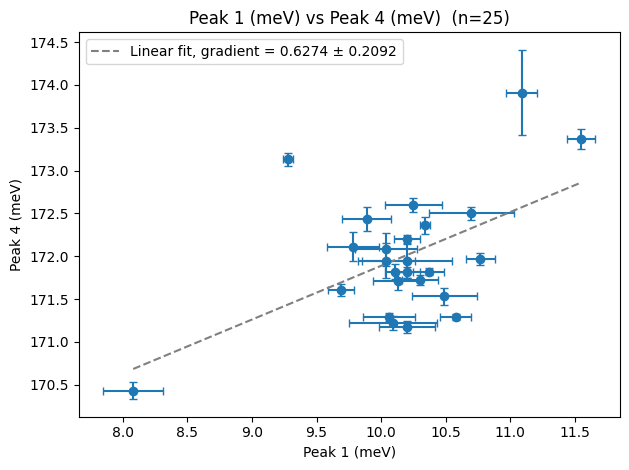

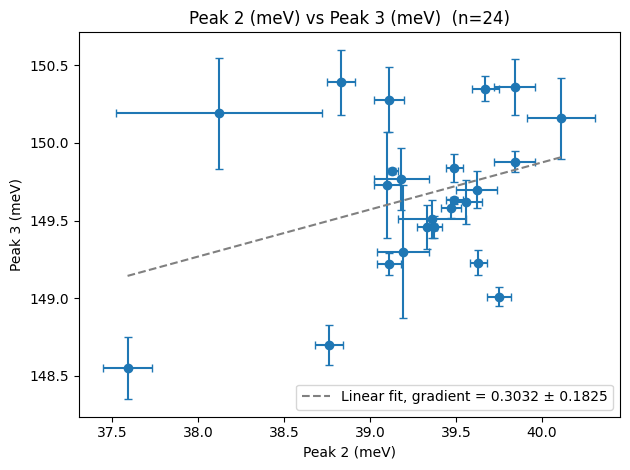

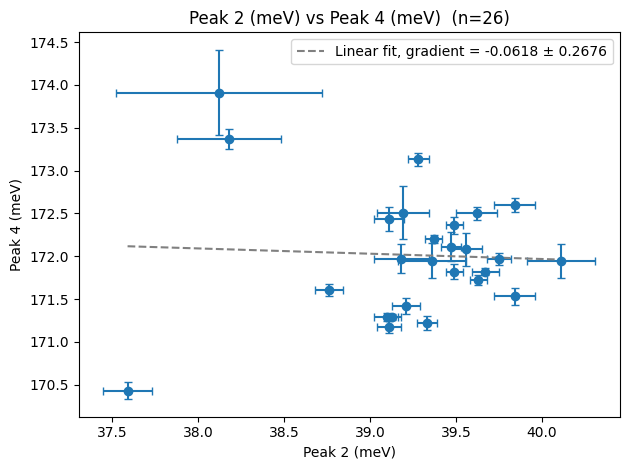

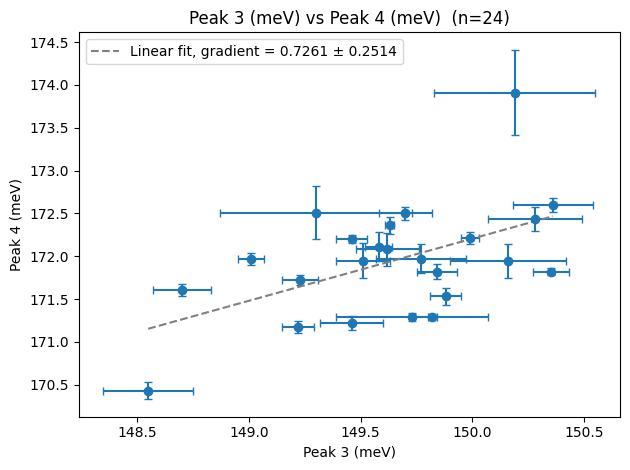

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import numpy as np

# Load data
file_path = r"C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\PL_strain_PSB_peaks_sample7_uncapped.csv"

df = pd.read_csv(file_path)
peaks = [
    ("Peak 1 (meV)", "Err 1"),
    ("Peak 2 (meV)", "Err 2"),
    ("Peak 3 (meV)", "Err 3"),
    ("Peak 4 (meV)", "Err 4"),
]

for (peak_x, err_x), (peak_y, err_y) in itertools.combinations(peaks, 2):

    # Drop rows only where THIS pair is missing
    sub = df[[peak_x, err_x, peak_y, err_y]].dropna()

    if len(sub) < 2:
        continue  # skip if not enough data points

    plt.figure()

    plt.errorbar(
        sub[peak_x],
        sub[peak_y],
        xerr=sub[err_x],
        yerr=sub[err_y],
        fmt='o',
        capsize=3
    )
    # Linear fit
    slope, intercept = np.polyfit(sub[peak_x], sub[peak_y], 1)
    # To get error in slope and intercept
    popt, pcov = np.polyfit(sub[peak_x], sub[peak_y], 1, cov=True)
    slope_err = np.sqrt(pcov[0,0])
    intercept_err = np.sqrt(pcov[1,1])

    # Plot fit line
    x_fit = np.linspace(sub[peak_x].min(), sub[peak_x].max(), 100)
    y_fit = slope * x_fit + intercept
    plt.plot(x_fit, y_fit, color='gray', linestyle='--', label=f'Linear fit, gradient = {slope:.4f} ± {slope_err:.4f}')
    plt.legend()
    plt.xlabel(peak_x)
    plt.ylabel(peak_y)
    plt.title(f"{peak_x} vs {peak_y}  (n={len(sub)})")
    plt.tight_layout()
    plt.show()
